# Libs and config

In [119]:
xd = [1, 2, 3, 43, 4]
xd[2:]

[3, 43, 4]

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_recall_curve,
    precision_score,
    average_precision_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

from xgboost import XGBClassifier

# import scikitplot as skplt

In [6]:
pd.set_option("display.max_columns", None)

# Data

In [27]:
df = pd.read_csv(
    "../data/df_cleaned.csv",
)
print(df.dtypes)
print(df.info())
df.head()

Customer_ID                  object
num_month                     int64
Age                           int64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Interest_Rate               float64
Num_of_Loan                   int64
Delay_from_due_date           int64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
Num_of_Delayed_Payment      float64
Occupation                   object
Credit_Mix                   object
Payment_Behaviour            object
Payment_of_Min_Amount        object
Student Loan                  int64
Not Specified                 int64
Home Equity Loan              int64
Mortgage Loan                 int64
Credit-Builder Loan           int64
Personal Loan               

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Student Loan,Not Specified,Home Equity Loan,Mortgage Loan,Credit-Builder Loan,Personal Loan,Debt Consolidation Loan,Auto Loan,Payday Loan,Credit_Score_binomial
0,CUS_0x1000,202201,17,30625.94,2706.161667,6.0,27.0,2,62,1.63,10.0,1562.91,26.612093,10.166667,42.94109,244.750283,252.924793,25.0,Lawyer,Bad,Low_spent_Large_value_payments,Yes,0,0,1,0,1,0,0,0,0,0
1,CUS_0x1000,202202,17,30625.94,2706.161667,6.0,27.0,2,62,1.63,11.0,1562.91,29.439759,10.250000,42.94109,176.132567,311.542510,23.0,Lawyer,Bad,High_spent_Small_value_payments,Yes,0,0,1,0,1,0,0,0,0,1
2,CUS_0x1000,202203,17,30625.94,2706.161667,6.0,27.0,2,62,1.63,11.0,1562.91,38.285928,10.333333,42.94109,109.056519,368.618557,28.0,Lawyer,Bad,High_spent_Medium_value_payments,Yes,0,0,1,0,1,0,0,0,0,1
3,CUS_0x1000,202204,17,30625.94,2706.161667,6.0,27.0,2,64,1.63,11.0,1562.91,32.843081,10.416667,42.94109,87.909909,419.765167,25.0,Lawyer,Bad,High_spent_Medium_value_payments,Yes,0,0,1,0,1,0,0,0,0,1
4,CUS_0x1000,202205,17,30625.94,2706.161667,6.0,27.0,2,67,2.63,11.0,1562.91,32.330508,10.500000,42.94109,191.834767,305.840309,25.0,Lawyer,Bad,Low_spent_Large_value_payments,Yes,0,0,1,0,1,0,0,0,0,1


In [83]:
numeric_columns = df.select_dtypes(
    include=["int64", "float32", "float64", "bool"]
).columns.to_list()
numeric_columns.remove("num_month")
numeric_columns.remove("Credit_Score_binomial")
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.to_list()
categorical_columns.remove("Customer_ID")
final_feautures = numeric_columns + categorical_columns
target = "Credit_Score_binomial"

# Prepare data

In [84]:
X = df[final_feautures].copy()
y = df[target]
X[categorical_columns] = X[categorical_columns].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.25
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(75000, 29)
(25000, 29)
(75000,)
(25000,)


# Modelling

## XGBoost

[0]	validation_0-logloss:0.57032	validation_1-logloss:0.57087
[1]	validation_0-logloss:0.54574	validation_1-logloss:0.54679
[2]	validation_0-logloss:0.52609	validation_1-logloss:0.52759
[3]	validation_0-logloss:0.51028	validation_1-logloss:0.51217
[4]	validation_0-logloss:0.49720	validation_1-logloss:0.49952
[5]	validation_0-logloss:0.48651	validation_1-logloss:0.48917
[6]	validation_0-logloss:0.47760	validation_1-logloss:0.48052
[7]	validation_0-logloss:0.46748	validation_1-logloss:0.47063
[8]	validation_0-logloss:0.45912	validation_1-logloss:0.46249
[9]	validation_0-logloss:0.45216	validation_1-logloss:0.45570
[10]	validation_0-logloss:0.44632	validation_1-logloss:0.45000
[11]	validation_0-logloss:0.44139	validation_1-logloss:0.44517
[12]	validation_0-logloss:0.43720	validation_1-logloss:0.44109
[13]	validation_0-logloss:0.43429	validation_1-logloss:0.43835
[14]	validation_0-logloss:0.43110	validation_1-logloss:0.43528
[15]	validation_0-logloss:0.42840	validation_1-logloss:0.43265
[1

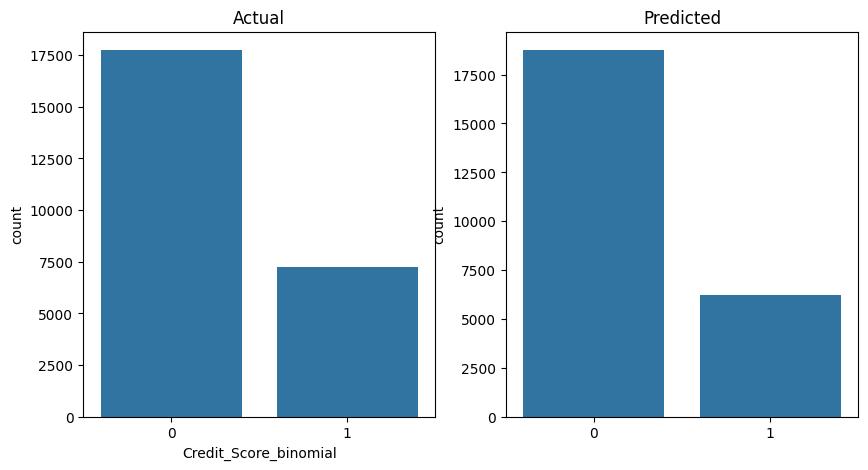

In [85]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    enable_categorical=True,
    early_stopping_rounds=20,
)

xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)])

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(
    x=y_test,
    ax=axes[0],
)

sns.countplot(x=y_pred, ax=axes[1])

axes[0].set_title("Actual")
axes[1].set_title("Predicted")

plt.show()

              precision    recall  f1-score   support

           0       0.86      0.91      0.89     17751
           1       0.75      0.64      0.69      7249

    accuracy                           0.83     25000
   macro avg       0.81      0.78      0.79     25000
weighted avg       0.83      0.83      0.83     25000



ROC-AUC: 0.87
, PR-AUC: 0.73


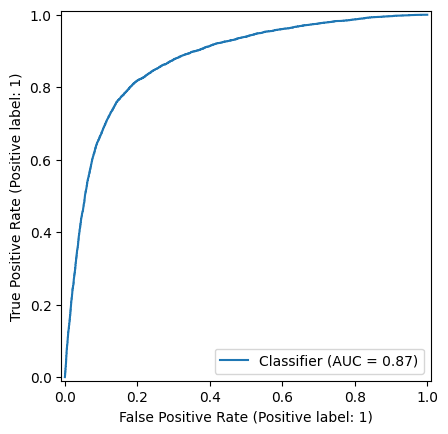

In [86]:
print(classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {round(roc_auc,2)}\n, PR-AUC: {round(pr_auc,2)}")

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

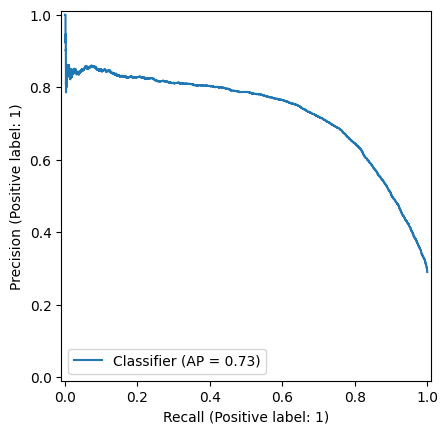

In [87]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba)

In [88]:
results = []
thresholds = np.arange(0.05, 1, 0.05)

for thresh in thresholds:
    t_y_pred = y_proba >= thresh

    tn, fp, fn, tp = confusion_matrix(y_test, t_y_pred).ravel()

    t_precision = precision_score(y_test, t_y_pred)
    t_recall = recall_score(y_test, t_y_pred)

    results.append(
        {
            "threshodl": thresh,
            "precision": t_precision,
            "recall": t_recall,
            "positive_preds": tp + fp,
            "true_positives": tp,
            "total_positives": tp + fn,
        }
    )

report = pd.DataFrame(results)
report

/Users/luisfernandocorcueraleon/Desktop/code/Credit-Score-Classification/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,threshodl,precision,recall,positive_preds,true_positives,total_positives
0,0.05,0.333520,0.987722,21468,7160,7249
1,0.10,0.449883,0.930611,14995,6746,7249
2,0.15,0.550960,0.871017,11460,6314,7249
3,0.20,0.593640,0.839564,10252,6086,7249
4,0.25,0.615893,0.823286,9690,5968,7249
5,0.30,0.639290,0.805352,9132,5838,7249
6,0.35,0.665133,0.777900,8478,5639,7249
7,0.40,0.697049,0.736377,7658,5338,7249
8,0.45,0.726393,0.683405,6820,4954,7249
9,0.50,0.748718,0.644503,6240,4672,7249


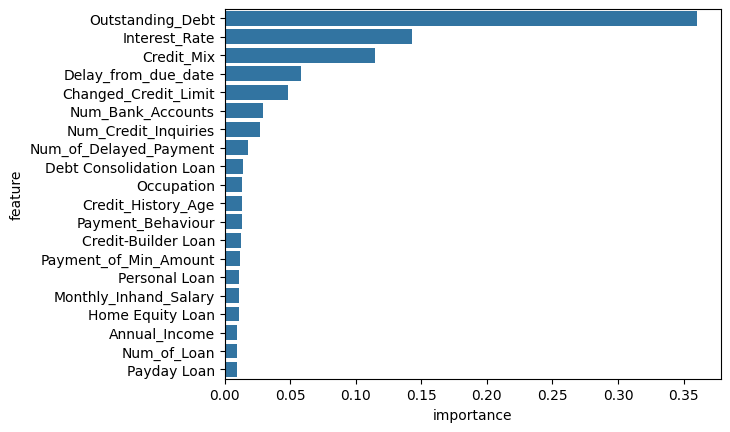

In [117]:
feature_names = X_train.columns
importances = xgb_model.feature_importances_

xgb_importance = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=False)

sns.barplot(data=xgb_importance.head(20), x="importance", y="feature")

plt.show()

## Random forest

In [95]:
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)],
    remainder="passthrough",
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
)

rf_pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", rf_model)])

In [ ]:
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [101]:
print(classification_report(y_test, y_pred_rf))
print(
    f"ROC AUC: {round(roc_auc_score(y_test, y_proba_rf),2)} \n PR-AUC: {round(average_precision_score(y_test,y_proba_rf),1)}"
)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85     17751
           1       0.63      0.64      0.64      7249

    accuracy                           0.79     25000
   macro avg       0.74      0.74      0.74     25000
weighted avg       0.79      0.79      0.79     25000

ROC AUC: 0.81 
 PR-AUC: 0.7


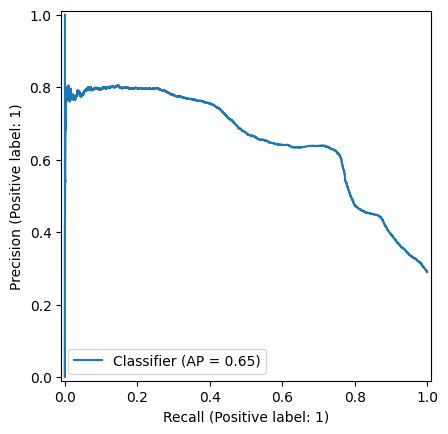

In [100]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf)
plt.show()

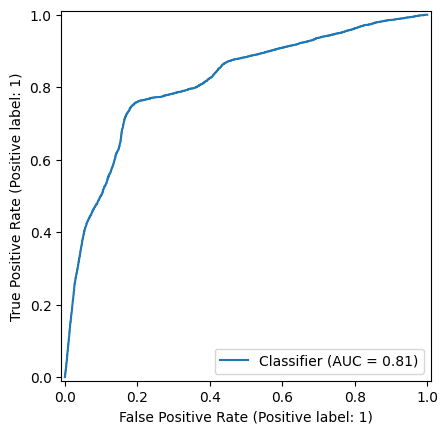

In [102]:
RocCurveDisplay.from_predictions(y_test, y_proba_rf)

In [105]:
feature_names_rf = rf_pipeline["preprocessor"].get_feature_names_out()

importances = rf_pipeline["classifier"].feature_importances_

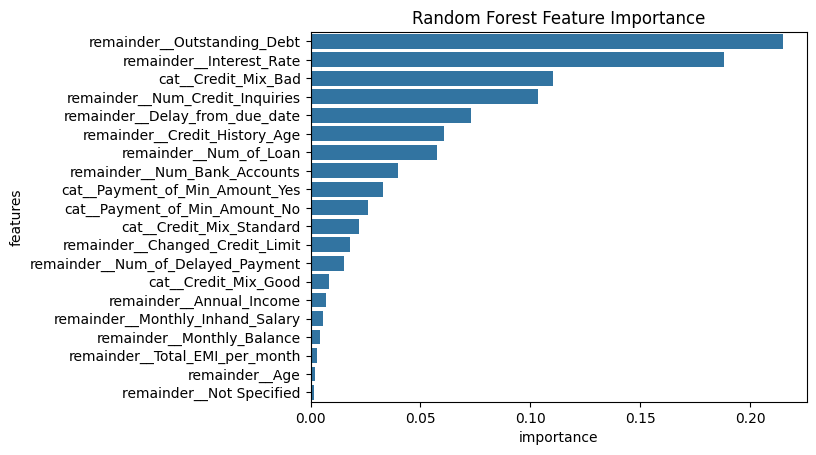

In [111]:
feature_importances_rf = pd.DataFrame(
    {"features": feature_names_rf, "importance": importances}
)
feature_importances_rf = feature_importances_rf.sort_values(
    by="importance", ascending=False
)

top_features = feature_importances_rf.head(20)

sns.barplot(data=top_features, x="importance", y="features")

plt.title("Random Forest Feature Importance")
plt.show()